In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpltern

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [102]:
all = 'momenta_all_events.txt'
delayed = 'momenta_delayed_events.txt'
direct = 'momenta_direct_events.txt'

In [103]:
from PCA_wspolczynniki import pca_kierunki

In [104]:
result_all = pca_kierunki(
    direct,
    return_extra=True
)

result_all["loadings"]

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
p2x,-0.008191,0.209377,-0.099911,0.573260,0.677013,0.387478,0.094686,-0.002750,0.005057
p2y,0.051501,-0.341436,0.526199,-0.332792,0.453259,-0.106747,0.525590,-0.005534,-0.004206
p2z,0.579672,0.018782,-0.018847,0.018918,-0.018784,-0.010721,0.003398,-0.282930,0.763142
p3x,0.012013,0.294705,0.602356,0.076645,-0.422718,0.592128,0.120773,0.020072,0.001416
p3y,0.001065,-0.450595,-0.126490,0.588939,-0.389070,-0.107497,0.520376,0.009683,-0.017257
p3z,0.577214,0.023961,-0.017633,0.010966,-0.011463,0.006899,-0.015601,-0.516517,-0.631352
p4x,0.022689,-0.446870,-0.432278,-0.369660,-0.013839,0.687423,0.057922,0.012161,0.005819
p4y,-0.017859,0.590441,-0.382626,-0.265776,-0.073575,-0.055583,0.652255,0.005119,-0.007426
p4z,0.571931,0.021339,-0.019131,0.011595,0.007344,-0.022178,-0.019107,0.807745,-0.136295


PC3: -21 -16 0 -51 -28 0 63 43 0

### PC1 (wyróżnione kierunki)    
    0.579538 * p2z  +   0.571808 * p3z  +   0.577622 * p4z
    (0, 0, 1, 0, 0, 1, 0, 0, 1)
    proponowany kierunek: p2z + p3z + p4z
recollision tunielowanego elektronu, który z powrotem do jonu wybija pozostałe 2e, i one jednocześnie wylatają. Czyli direct (e, 3e)

Czyli tu PCA wyróżniła kierunek mocnej korelacji pędów elektronów wzdłuz osi Z, czyli osi E(t), która właśnie wprowadza w oscylacje ten potencjał jonu i wybija z tego elektron tunelowaniem.

### deviations, nierównomierny rozkład: PC8 
    -0.339156 * p2z  +   0.816006 * p3z  +   -0.466553 * p4z
    (0, 0, -1/2, 0, 0, 1, 0, 0, -1/2)
    proponowany kierunek: p3z - 1/2(p2z + p4z)

### PC9
    0.739205 * p2z -0.666307 * p4z
    (0, 0, 1, 0, 0, 0, 0, 0, -1)
    prop. kier.: p2z - p4z

In [105]:
result_all["explained_variance"]

,PC,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.300261,0.300261
1,PC2,0.131498,0.431760
2,PC3,0.120607,0.552366
3,PC4,0.115788,0.668154
4,PC5,0.110489,0.778643
5,PC6,0.097366,0.876009
6,PC7,0.090345,0.966354
7,PC8,0.019030,0.985384
8,PC9,0.014616,1.000000


Jeżeli 

In [106]:
result_direct = pca_kierunki(
    direct,
    return_extra=True
)

result_direct["loadings"]

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
p2x,-0.008191,0.209377,-0.099911,0.573260,0.677013,0.387478,0.094686,-0.002750,0.005057
p2y,0.051501,-0.341436,0.526199,-0.332792,0.453259,-0.106747,0.525590,-0.005534,-0.004206
p2z,0.579672,0.018782,-0.018847,0.018918,-0.018784,-0.010721,0.003398,-0.282930,0.763142
p3x,0.012013,0.294705,0.602356,0.076645,-0.422718,0.592128,0.120773,0.020072,0.001416
p3y,0.001065,-0.450595,-0.126490,0.588939,-0.389070,-0.107497,0.520376,0.009683,-0.017257
p3z,0.577214,0.023961,-0.017633,0.010966,-0.011463,0.006899,-0.015601,-0.516517,-0.631352
p4x,0.022689,-0.446870,-0.432278,-0.369660,-0.013839,0.687423,0.057922,0.012161,0.005819
p4y,-0.017859,0.590441,-0.382626,-0.265776,-0.073575,-0.055583,0.652255,0.005119,-0.007426
p4z,0.571931,0.021339,-0.019131,0.011595,0.007344,-0.022178,-0.019107,0.807745,-0.136295


In [107]:
result_delayed = pca_kierunki(
    delayed,
    return_extra=True
)

result_delayed["loadings"]

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
p2x,-0.064770,0.081733,-0.437221,-0.646481,0.282935,-0.171851,0.504725,-0.123684,0.019850
p2y,0.027288,-0.489974,0.078711,0.235238,0.663426,0.449983,0.220937,-0.060072,-0.051064
p2z,0.562671,0.140927,-0.005857,0.068645,0.006191,-0.056989,-0.019308,-0.610381,-0.531574
p3x,-0.003421,0.330139,-0.299709,0.700810,0.100638,-0.296818,0.441003,0.075889,0.107540
p3y,0.027164,-0.401510,-0.365965,0.084290,-0.659784,0.371854,0.341887,-0.064973,-0.048138
p3z,0.535205,-0.019391,-0.046655,-0.101000,0.030439,-0.012651,0.080954,0.764349,-0.330050
p4x,0.051244,-0.280706,0.674605,-0.051430,-0.168416,-0.405458,0.514149,-0.045468,0.040789
p4y,-0.071242,0.618822,0.348653,-0.086577,-0.070904,0.601472,0.336346,0.034025,-0.042969
p4z,0.619327,0.032703,-0.004871,-0.058588,0.003702,0.109696,-0.025778,-0.105328,0.766879


In [108]:
all_columns = [
        "p1x", "p1y", "p1z",
        "p2x", "p2y", "p2z",
        "p3x", "p3y", "p3z",
        "p4x", "p4y", "p4z"
    ]
df = pd.read_csv(all, sep=",", header=None, names=all_columns)

df["P_col"] = df["p2z"] + df["p3z"] + df["p4z"]
df["A3"] = df["p3z"] - (df["p2z"] + df["p4z"]) / 2
df["R24"] = df["p2z"] - df["p4z"]

df[["p2z", "p3z", "p4z", "P_col", "A3", "R24"]].head()

summary = df[["P_col", "A3", "R24"]].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
P_col,4872.0,-0.079612,5.408208,-10.724501,-5.074563,-0.480091,5.053960,10.332804
A3,4872.0,0.030376,1.702133,-5.474262,-1.093093,0.045412,1.139725,6.579817
R24,4872.0,0.044856,1.973148,-7.513469,-1.228766,0.050530,1.334478,6.899411


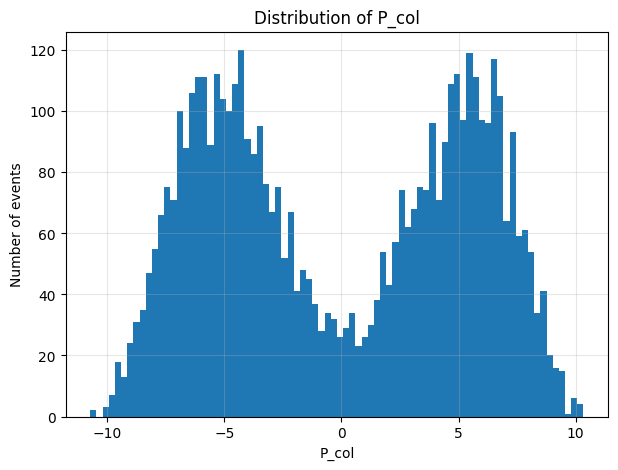

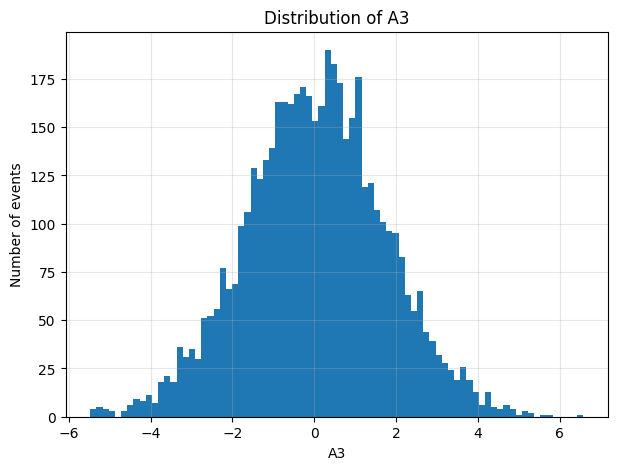

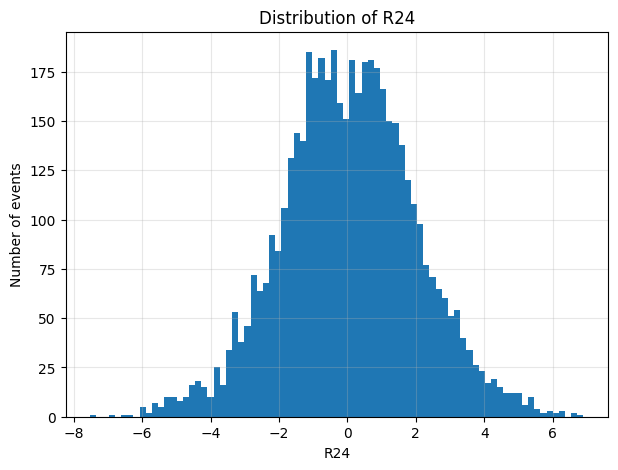

In [109]:
for col in ["P_col", "A3", "R24"]:
    plt.figure(figsize=(7, 5))
    plt.hist(df[col], bins=80)
    plt.xlabel(col)
    plt.ylabel("Number of events")
    plt.title(f"Distribution of {col}")
    plt.grid(True, alpha=0.3)
    plt.show()

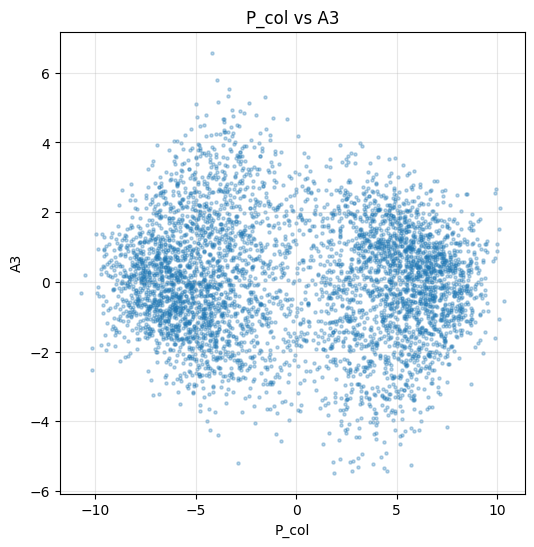

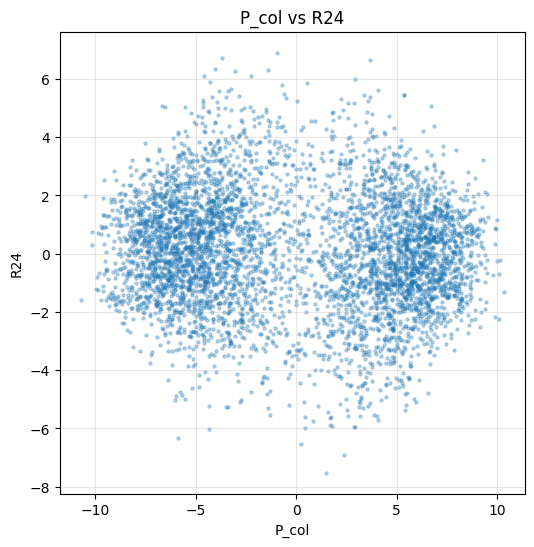

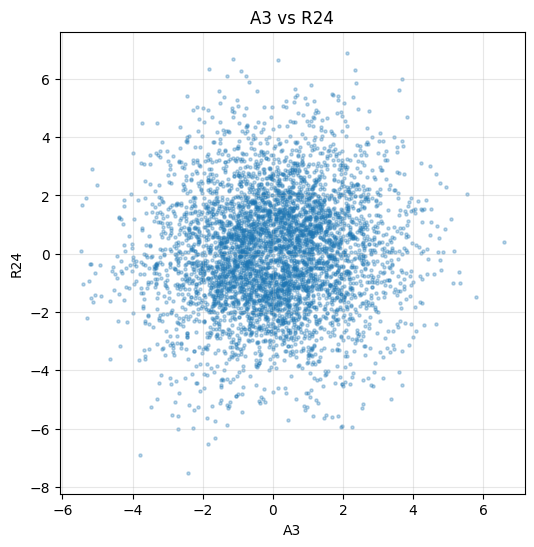

In [110]:
pairs = [
    ("P_col", "A3"),
    ("P_col", "R24"),
    ("A3", "R24")
]

for x, y in pairs:
    plt.figure(figsize=(6, 6))
    plt.scatter(df[x], df[y], s=5, alpha=0.3)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.grid(True, alpha=0.3)
    plt.show()

In [111]:
all_columns = [
    "p1x", "p1y", "p1z",
    "p2x", "p2y", "p2z",
    "p3x", "p3y", "p3z",
    "p4x", "p4y", "p4z"
]

df = pd.read_csv(file, sep=",", header=None, names=all_columns)

electron_columns = [
    "p2x", "p2y", "p2z",
    "p3x", "p3y", "p3z",
    "p4x", "p4y", "p4z"
]

df_e = df[electron_columns]
df_e.head()

,p2x,p2y,p2z,p3x,p3y,p3z,p4x,p4y,p4z
0,-0.105585,0.209122,-2.997380,-0.476154,0.458334,-1.073163,1.086990,-1.286031,-3.396191
1,-0.587539,0.415075,-2.004660,0.502676,0.215232,-1.877260,0.354641,0.159951,-3.073955
2,0.345800,-0.558209,-2.879117,-0.706763,0.131315,-3.158056,-0.878761,-1.535917,-0.390050
3,0.094764,0.797247,3.059864,0.074589,0.320725,1.775028,-0.949737,-1.078361,1.914962
4,0.452822,0.529824,0.494379,0.064172,-0.003324,2.379804,-0.542459,0.108178,2.473663


In [112]:
df_e.shape

(2042, 9)

In [113]:
df_e.describe()

,p2x,p2y,p2z,p3x,p3y,p3z,p4x,p4y,p4z
count,2042.000000,2042.000000,2042.000000,2042.000000,2042.000000,2042.000000,2042.000000,2042.000000,2042.000000
mean,0.021617,0.028428,-0.009423,-0.016344,0.043952,-0.019160,-0.005849,-0.005667,-0.044664
std,0.510586,0.544474,2.309511,0.533071,0.524705,2.320795,0.692345,0.698441,2.393069
min,-2.235576,-2.489275,-4.571756,-2.094896,-2.231720,-5.070259,-2.213781,-2.612558,-4.884493
25%,-0.270164,-0.249495,-2.169940,-0.315373,-0.246245,-2.201305,-0.368076,-0.364579,-2.251007
50%,0.007288,0.026202,-0.262291,-0.024502,0.028180,-0.150684,-0.011227,0.004077,-0.132161
75%,0.301632,0.312052,2.199522,0.274694,0.340916,2.165578,0.361195,0.362547,2.193447
max,2.351930,2.204858,4.974531,2.395202,2.250640,5.106394,2.340717,2.625329,4.932914


In [114]:
df_e.isna().sum()

p2x    0
p2y    0
p2z    0
p3x    0
p3y    0
p3z    0
p4x    0
p4y    0
p4z    0
dtype: int64

In [115]:
X = df_e.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [116]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

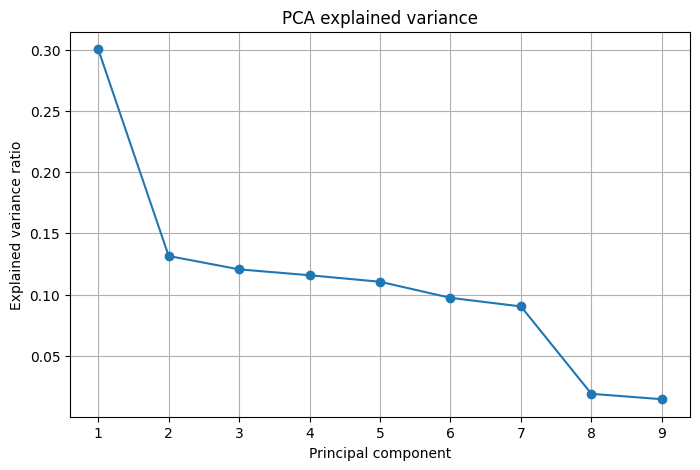

In [117]:
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance")
plt.grid(True)
plt.show()

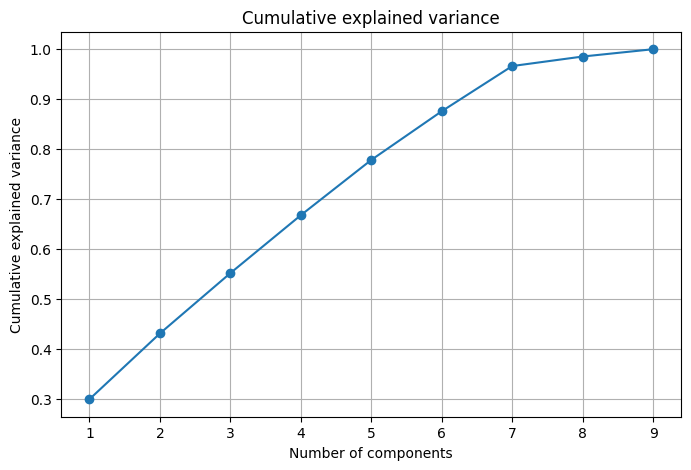

In [118]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance")
plt.grid(True)
plt.show()

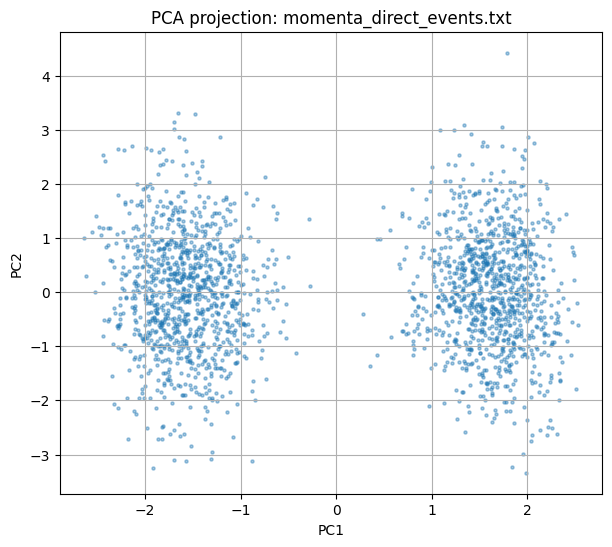

In [119]:
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection: {file}")
plt.grid(True)
plt.show()

In [120]:
# Loadings: вклад исходных переменных в каждую главную компоненту

loadings = pd.DataFrame(
    pca.components_.T,
    index=electron_columns,
    columns=[f"PC{i+1}" for i in range(len(electron_columns))]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
p2x,-0.008191,0.209377,-0.099911,0.573260,0.677013,0.387478,0.094686,-0.002750,0.005057
p2y,0.051501,-0.341436,0.526199,-0.332792,0.453259,-0.106747,0.525590,-0.005534,-0.004206
p2z,0.579672,0.018782,-0.018847,0.018918,-0.018784,-0.010721,0.003398,-0.282930,0.763142
p3x,0.012013,0.294705,0.602356,0.076645,-0.422718,0.592128,0.120773,0.020072,0.001416
p3y,0.001065,-0.450595,-0.126490,0.588939,-0.389070,-0.107497,0.520376,0.009683,-0.017257
p3z,0.577214,0.023961,-0.017633,0.010966,-0.011463,0.006899,-0.015601,-0.516517,-0.631352
p4x,0.022689,-0.446870,-0.432278,-0.369660,-0.013839,0.687423,0.057922,0.012161,0.005819
p4y,-0.017859,0.590441,-0.382626,-0.265776,-0.073575,-0.055583,0.652255,0.005119,-0.007426
p4z,0.571931,0.021339,-0.019131,0.011595,0.007344,-0.022178,-0.019107,0.807745,-0.136295
